# Training Dynamics

Train a small GPT model
([Radford et al., 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf))
live and observe how loss, gradients, and activations evolve.
Demonstrates the effect of learning rate on convergence.

**Prerequisites:** `uv sync --extra dev --extra analysis`

In [1]:
import mlx.core as mx

from lmxlab.data.batching import batch_iterator
from lmxlab.data.tokenizer import CharTokenizer
from lmxlab.models.base import LanguageModel
from lmxlab.models.gpt import gpt_tiny
from lmxlab.training.callbacks import MetricsLogger
from lmxlab.training.config import TrainConfig
from lmxlab.training.trainer import Trainer

/Users/michaelellis/Projects/lmt-metal/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup: Data and Model

In [2]:
TEXT = (
    "To be or not to be that is the question "
    "whether tis nobler in the mind to suffer "
) * 50

tok = CharTokenizer(TEXT)
tokens = mx.array(tok.encode(TEXT), dtype=mx.int32)

# 90/10 split
split = int(0.9 * len(tokens))
train_tokens, val_tokens = tokens[:split], tokens[split:]
print(f"Train: {len(train_tokens)} tokens, Val: {len(val_tokens)} tokens")

Train: 3645 tokens, Val: 405 tokens


In [3]:
from dataclasses import replace

cfg = gpt_tiny()
cfg = replace(cfg, vocab_size=tok.vocab_size)
model = LanguageModel(cfg)
mx.eval(model.parameters())
print(f"Model: {model.count_parameters():,} params")

Model: 68,288 params


## Train and Collect Metrics

In [4]:
train_config = TrainConfig(
    learning_rate=1e-3,
    max_steps=200,
    batch_size=4,
    warmup_steps=10,
    compile_step=False,
)

logger = MetricsLogger(log_interval=50)
trainer = Trainer(model, train_config, callbacks=[logger])

def make_data():
    yield from batch_iterator(train_tokens, batch_size=4, seq_len=32, shuffle=True)

history = trainer.train(make_data())
print(f"Final loss: {history[-1]['loss']:.4f}")

Training complete: 28 steps in 0.1s
Final loss: 1.3014


## Plot Loss Curve

In [5]:
try:
    from lmxlab.analysis.plotting import plot_loss_curves

    losses = [h["loss"] for h in history]
    fig = plot_loss_curves(losses)
    fig.show()
except ImportError:
    print("Install matplotlib: uv sync --extra analysis")

/var/folders/b3/kr49kw115k73d4m4rh1lpc400000gn/T/ipykernel_43760/1760012444.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


## Gradient Flow Analysis

Check gradient magnitudes across layers to detect
vanishing or exploding gradients.

In [6]:
try:
    from lmxlab.analysis.plotting import plot_gradient_flow

    fig = plot_gradient_flow(model)
    fig.show()
except ImportError:
    print("Install matplotlib: uv sync --extra analysis")

/var/folders/b3/kr49kw115k73d4m4rh1lpc400000gn/T/ipykernel_43760/3536036018.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


## Activation Norms by Layer

Check how activation magnitudes change through the model.
Healthy training should show roughly stable norms.

In [7]:
from lmxlab.analysis.activations import ActivationCapture

test_tokens = mx.zeros((1, 16), dtype=mx.int32)
with ActivationCapture(model) as cap:
    model(test_tokens)

norms = cap.layer_norms()
print("Activation L2 norms by layer:")
for key, val in sorted(norms.items()):
    print(f"  {key}: {val:.4f}")

Activation L2 norms by layer:
  layer_0/input: 5.6362
  layer_0/output: 47.0407
  layer_1/input: 47.0407
  layer_1/output: 58.2582


In [8]:
try:
    from lmxlab.analysis.plotting import plot_layer_norms

    fig = plot_layer_norms(cap.activations)
    fig.show()
except ImportError:
    print("Install matplotlib: uv sync --extra analysis")

/var/folders/b3/kr49kw115k73d4m4rh1lpc400000gn/T/ipykernel_43760/3748136649.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


## Effect of Learning Rate

Compare training curves at different learning rates.

In [9]:
results = {}
for lr in [1e-4, 1e-3, 1e-2]:
    mx.random.seed(42)
    m = LanguageModel(cfg)
    mx.eval(m.parameters())
    tc = TrainConfig(learning_rate=lr, max_steps=100, batch_size=4, warmup_steps=5, compile_step=False)
    t = Trainer(m, tc)
    h = t.train(batch_iterator(train_tokens, batch_size=4, seq_len=32, shuffle=True))
    results[f"lr={lr}"] = [s["loss"] for s in h]
    print(f"LR={lr}: final loss = {h[-1]['loss']:.4f}")

LR=0.0001: final loss = 2.4207
LR=0.001: final loss = 1.5088


LR=0.01: final loss = 2.1229


/var/folders/b3/kr49kw115k73d4m4rh1lpc400000gn/T/ipykernel_43760/1475826130.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


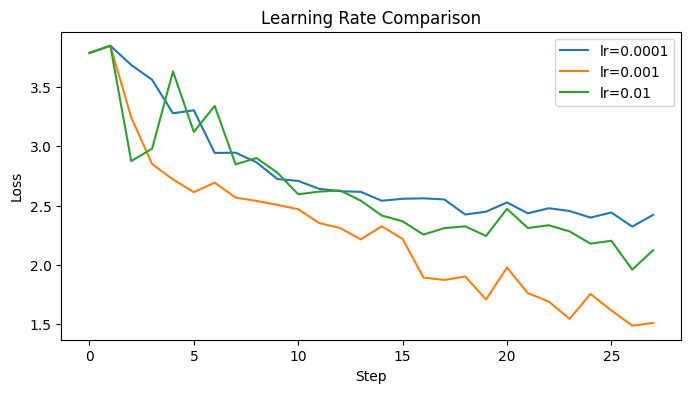

In [10]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    for label, losses in results.items():
        ax.plot(losses, label=label)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Learning Rate Comparison")
    ax.legend()
    fig.show()
except ImportError:
    print("Install matplotlib for plots")

## References

- Radford et al. (2019). [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf). OpenAI Technical Report.